In [155]:
import matplotlib.pyplot as plt
import ast
import pandas as pd
import numpy as np
import cnn_surgery.utils.metrics as metrics

In [156]:
DATASET = 'svhn_cropped'
file_path = f'./../datar/{DATASET}_class_evaluation_baselines_relative.csv'
df = pd.read_csv(file_path) 

In [157]:
df.final_pred

0        [0.17020881, 0.7723449, 0.7692933, 0.49595425,...
1        [0.13773613, 0.8129131, 0.85478806, 0.20425892...
2        [0.17904277, 0.7197864, 0.8220079, 0.35467863,...
3        [0.23043337, 0.76702887, 0.8650389, 0.66121453...
4        [0.22652704, 0.7813987, 0.8410078, 0.4590062, ...
                               ...                        
74935    [0.5420649, 0.8860261, 0.93561226, 0.44438398,...
74936    [0.4987542, 0.88010794, 0.9387895, 0.42756435,...
74937    [0.5366682, 0.8884694, 0.93840176, 0.4491421, ...
74938    [0.5160779, 0.84330535, 0.90785813, 0.410298, ...
74939    [0.55916494, 0.8843882, 0.93028843, 0.433376, ...
Name: final_pred, Length: 74940, dtype: object

In [158]:
def mse(pred: list, real: list):
    return np.mean((np.array(pred) - np.array(real)) ** 2)


In [159]:
# calculate metrics
df['max_difference'] = df.apply(lambda row: metrics.max_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['mean_difference'] = df.apply(lambda row: metrics.mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['clipped_negative_mean_difference'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
#df['relative_clipped_negative_mean_difference'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class'], proportional=True), axis=1)
df['target_difference'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['mse_pred_after'] = df.apply(lambda row: mse(ast.literal_eval(row['final_pred']), ast.literal_eval(row['accuracy_after'])), axis=1)

In [160]:
# filters
print(f"Original number of rows: {len(df)}")
df_filtered = df[~df['original_accuracy'].apply(lambda x: 0.0 in ast.literal_eval(x))]
df_filtered = df_filtered[~df_filtered.apply(lambda row: ast.literal_eval(row['original_accuracy'])[row['target_class']] < 0.1, axis=1)]
print(f"Number of rows after filtering: {len(df_filtered)}")
df_filtered = df_filtered[~(df_filtered['distance_travelled'] < 1.0)]
df_filtered = df_filtered[~(df_filtered['steps'] >= 1999)]
print(f"Number of rows after additional filtering: {len(df_filtered)}")
df = df_filtered



Original number of rows: 74940
Number of rows after filtering: 21751
Number of rows after additional filtering: 13838


In [161]:
print(len(df))

13838


In [162]:
print_datasets = {'mnist': 'MNIST', 'fashion_mnist': 'Fashion-MNIST', 'cifar10': 'CIFAR-10', 'svhn_cropped': 'SVHN'}

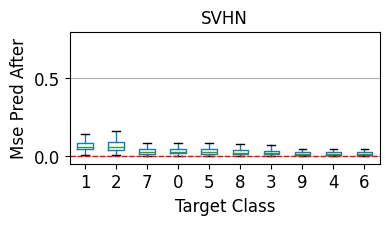

In [163]:
METRIC = 'mse_pred_after'

# Group the data
grouped = df.groupby(['dataset','meta_network','loss_fn', 'target_class', 'stopping_criterium'])
# sort groups by mean metric (descending)
grouped = sorted(grouped, key=lambda x: x[1][METRIC].mean(), reverse=True)

fig, ax = plt.subplots(figsize=(4, 4))
fontsize = 12

# Define positions for each group
positions = []
labels = []
width = 0.1  # Width of each boxplot
offset = 0

for i, (name, group) in enumerate(grouped):
    group.boxplot(column=METRIC, positions=[offset], widths=width, ax=ax, showfliers=False)
    positions.append(offset)
    labels.append(str(name).split(", ")[3])
    offset += 0.2

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=0)
ax.set_title(print_datasets[DATASET], fontsize=fontsize)
ax.set_ylabel(METRIC.replace('_', ' ').title(), fontsize=fontsize)
ax.set_xlabel('Target Class', fontsize=fontsize)
ax.set_ylim(-0.05, 0.8)
ax.grid(axis='x')
ax.axhline(0, color='red', linestyle='--', linewidth=1)

# smaller margins
ax.margins(x=0.02)          # remove auto-padding on x-axis
ax.set_xlim(min(positions)-0.1, max(positions)+0.1)  # manual tight bounds
ax.set_aspect('equal', adjustable='box')

# bigger font
ax.tick_params(axis='both', which='major', labelsize=fontsize)


ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig(f"Per_Class_{DATASET}_{METRIC}.png", bbox_inches="tight")
plt.show()